# 💊 Predicting Medical Insurance Charges — Linear Regression

**Dataset:** Medical Cost Personal Dataset (Kaggle)  
**Target Variable:** `charges` — Annual medical insurance cost (USD) for an individual  
**Algorithm:** Linear Regression (scikit-learn)  

---

## Project Goal

Given a person's demographic and lifestyle information (age, BMI, smoking status, etc.),  
can we predict how much they'll be charged for medical insurance?

This is a **regression problem** — the output is a continuous number (cost in dollars),  
not a category. Linear regression is the natural starting point for this type of problem.

---

## What This Notebook Covers

| Step | Description |
|------|-------------|
| 1 | Setup and import Libraries. |
| 2 | Load and explore the dataset  |
| 3 | Simple Linear Regression — Age vs Charges (Non-Smokers Only) |
| 4 | Multiple Linear Regression — Age + BMI (Non-Smokers) |
| 5 | Exploring Smoking Status  |
| 6 | Encoding Categorical Features — Label Encoding |
| 7 | Final model — all features combined |

---

## Why Linear Regression?

Linear regression models the relationship between input features and a continuous target  
by fitting a straight line (or hyperplane in multiple dimensions) through the data.

The model learns a **weight (coefficient)** for each feature, representing how much  
that feature contributes to the predicted charge. The goal during training is to minimise  
the **Root Mean Squared Error (RMSE)** — the average distance between predictions and actual values.

For example:
```
predicted_charge = w1×age + w2×bmi + w3×smoker_code + ... + bias
```

## 1. Setup — Install and Import Libraries

In [ ]:
# Install scikit-learn if it's not already available in this environment.
# In Google Colab this is usually pre-installed, but included here for safety.
!pip install scikit-learn --quiet

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

# Consistent plot styling across all visualisations
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 20)

## 2. Load the Dataset

The dataset (`medical.csv`) contains 1,338 rows and 7 columns describing individual  
insurance policyholders: their age, sex, BMI, number of children, smoking status,  
US region, and annual medical charges.

> **Note:** The upload cell below is specific to Google Colab.  
> If running locally, replace it with: `medical_df = pd.read_csv('medical.csv')`

In [2]:
# Upload the CSV file from your local machine into the Colab session.
# A file picker will appear — select medical.csv.
from google.colab import files
uploaded = files.upload()

Saving medical.csv to medical.csv


In [3]:
# Load the uploaded CSV into a DataFrame
medical_df = pd.read_csv('medical.csv')

# Preview the first few rows
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Column names, data types, and non-null counts
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# Summary statistics for numeric columns — useful for spotting outliers and value ranges
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 3. Simple Linear Regression — Age vs Charges (Non-Smokers Only)

We start with the simplest possible model: **one input feature predicting one output**.

We filter to non-smokers first because smokers have significantly higher and more variable charges.  
Including them in an early single-feature model would obscure the underlying age-charge relationship  
and make the linear fit misleading.



In [6]:
# Filter the dataset to non-smokers only for this initial exploration
non_smoker_df = medical_df[medical_df.smoker == 'no']

print(f"Non-smoker records: {len(non_smoker_df):,} out of {len(medical_df):,} total")

Non-smoker records: 1,064 out of 1,338 total


In [7]:
# Visualise the relationship between age and charges for non-smokers
fig = px.scatter(
    non_smoker_df,
    x='age', y='charges',
    title='Age vs Insurance Charges (Non-Smokers)',
    labels={'age': 'Age (years)', 'charges': 'Annual Charges (USD)'},
    opacity=0.6
)
fig.show()

In [8]:
# Define the single input feature (age) and the target (charges)
target_single = non_smoker_df['charges']
input_single  = non_smoker_df[['age']]   # double brackets → keeps it as a DataFrame (required by sklearn)

# Initialise and train the model
model_single = LinearRegression()
model_single.fit(input_single, target_single)

# Generate predictions on the training data
pred_single = model_single.predict(input_single)

# Report the learned coefficient and intercept
print(f"Coefficient (age weight): ${model_single.coef_[0]:.2f}")
print(f"Intercept (base charge):  ${model_single.intercept_:.2f}")
print(f"\nInterpretation: Each additional year of age adds ~${model_single.coef_[0]:.0f} to predicted charges.")

Coefficient (age weight): $267.25
Intercept (base charge):  $-2091.42

Interpretation: Each additional year of age adds ~$267 to predicted charges.


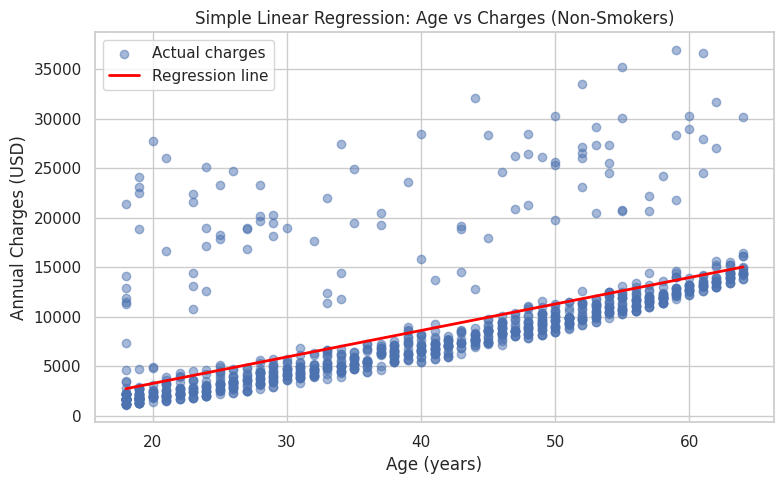

In [9]:
# Overlay the regression line on the scatter plot to see how well it fits
plt.figure(figsize=(8, 5))
plt.scatter(input_single, target_single, alpha=0.5, label='Actual charges')
plt.plot(input_single.sort_values('age'),
         model_single.predict(input_single.sort_values('age')),
         color='red', linewidth=2, label='Regression line')
plt.title('Simple Linear Regression: Age vs Charges (Non-Smokers)')
plt.xlabel('Age (years)')
plt.ylabel('Annual Charges (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Multiple Linear Regression — Age + BMI (Non-Smokers)

Adding a second feature (BMI) lets the model capture more of the variation in charges.  
With two input features, the model fits a **plane** through 3D space instead of a line.


In [10]:
# Visualise how BMI relates to charges among non-smokers
fig = px.scatter(
    non_smoker_df,
    x='bmi', y='charges',
    title='BMI vs Insurance Charges (Non-Smokers)',
    labels={'bmi': 'Body Mass Index', 'charges': 'Annual Charges (USD)'},
    opacity=0.6
)
fig.show()

In [11]:
# Two input features: age and BMI
inputs_multi  = non_smoker_df[['age', 'bmi']]
targets_multi = non_smoker_df['charges']

model_multi = LinearRegression()
model_multi.fit(inputs_multi, targets_multi)
pred_multi = model_multi.predict(inputs_multi)

# Report the learned weights for each feature
print("Feature coefficients:")
for feature, coef in zip(['age', 'bmi'], model_multi.coef_):
    print(f"  {feature:>5}: ${coef:.2f}")
print(f"\nIntercept: ${model_multi.intercept_:.2f}")

Feature coefficients:
    age: $266.88
    bmi: $7.08

Intercept: $-2293.63


## 5. Exploring Smoking Status — Does It Matter?

Before encoding smoker status as a feature, we first visualise its impact.  
If smokers and non-smokers have clearly different charge distributions,  
then including `smoker` as a feature should significantly improve the model.

In [12]:
# Side-by-side distribution of charges by smoking status
fig = px.histogram(
    medical_df, x='charges', color='smoker',
    barmode='overlay', opacity=0.7,
    title='Distribution of Charges: Smokers vs Non-Smokers',
    labels={'charges': 'Annual Charges (USD)', 'smoker': 'Smoker'},
    color_discrete_map={'yes': '#e74c3c', 'no': '#3498db'}
)
fig.show()

In [13]:
# Train a model on smokers only — age vs charges
smoker_df      = medical_df[medical_df.smoker == 'yes']
inputs_smoker  = smoker_df[['age']]
targets_smoker = smoker_df['charges']

model_smoker = LinearRegression()
model_smoker.fit(inputs_smoker, targets_smoker)
pred_smoker = model_smoker.predict(inputs_smoker)

print(f"Smoker model — Age coefficient: ${model_smoker.coef_[0]:.2f}")
print(f"Non-smoker model — Age coefficient: ${model_single.coef_[0]:.2f}")
print(f"\nSmokers pay roughly ${model_smoker.intercept_ - model_single.intercept_:.0f} more at baseline.")

Smoker model — Age coefficient: $305.24
Non-smoker model — Age coefficient: $267.25

Smokers pay roughly $22386 more at baseline.


## 6. Encoding Categorical Features — Label Encoding

Machine learning models require **numeric input only**. Columns like `smoker` ('yes'/'no')  
and `sex` ('male'/'female') are text — we need to convert them to numbers.

**Label encoding** maps each category to an integer:
- `smoker`: yes → 1, no → 0  
- `sex`: male → 1, female → 0

We also compute the **Pearson correlation** between each encoded column and `charges`  
to measure how strongly each feature is linearly related to the target.  
Values closer to 1.0 or -1.0 indicate a stronger relationship.

In [14]:
# Encode smoking status: Yes → 1, No → 0
smoker_map = {'yes': 1, 'no': 0}
medical_df['smoker_code'] = medical_df.smoker.map(smoker_map)

# Pearson correlation between smoker_code and charges
# A high positive value means smokers tend to have higher charges
smoker_corr = medical_df.charges.corr(medical_df.smoker_code)
print(f"Correlation between smoker status and charges: {smoker_corr:.4f}")
print("→ Strong positive correlation — smokers pay significantly more.")

Correlation between smoker status and charges: 0.7873
→ Strong positive correlation — smokers pay significantly more.


In [15]:
# Encode sex: Female → 0, Male → 1
sex_map = {'female': 0, 'male': 1}
medical_df['sex_code'] = medical_df.sex.map(sex_map)

# Pearson correlation between sex_code and charges
sex_corr = medical_df.charges.corr(medical_df.sex_code)
print(f"Correlation between sex and charges: {sex_corr:.4f}")
print("→ Weak correlation — sex is a minor predictor of charges compared to smoker status.")

Correlation between sex and charges: 0.0573
→ Weak correlation — sex is a minor predictor of charges compared to smoker status.


## 7. Model with All Numeric and Encoded Features

Now we train on all available numeric features:  
`age`, `bmi`, `children`, `smoker_code`, `sex_code`

This is our first model trained on the **full dataset** (smokers + non-smokers combined),  
using encoded categorical features so the model can capture the effect of smoking and sex.

In [18]:
# Select all numeric and label-encoded features
inputs_v1  = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code']]
targets_v1 = medical_df['charges']

model_v1 = LinearRegression()
model_v1.fit(inputs_v1, targets_v1)
pred_v1 = model_v1.predict(inputs_v1)

# Model performance metrics
rmse_v1 = root_mean_squared_error(targets_v1, pred_v1)
r2_v1   = r2_score(targets_v1, pred_v1)

print("Model v1 — Age, BMI, Children, Smoker, Sex")
print(f"  RMSE : ${rmse_v1:,.2f}")
print(f"  R²   : {r2_v1:.4f}  ({r2_v1*100:.1f}% of variance explained)")
print()
print("Feature coefficients:")
for feature, coef in zip(inputs_v1.columns, model_v1.coef_):
    print(f"  {feature:<15}: ${coef:.2f}")

Model v1 — Age, BMI, Children, Smoker, Sex
  RMSE : $6,056.10
  R²   : 0.7497  (75.0% of variance explained)

Feature coefficients:
  age            : $257.73
  bmi            : $322.36
  children       : $474.41
  smoker_code    : $23823.39
  sex_code       : $-128.64


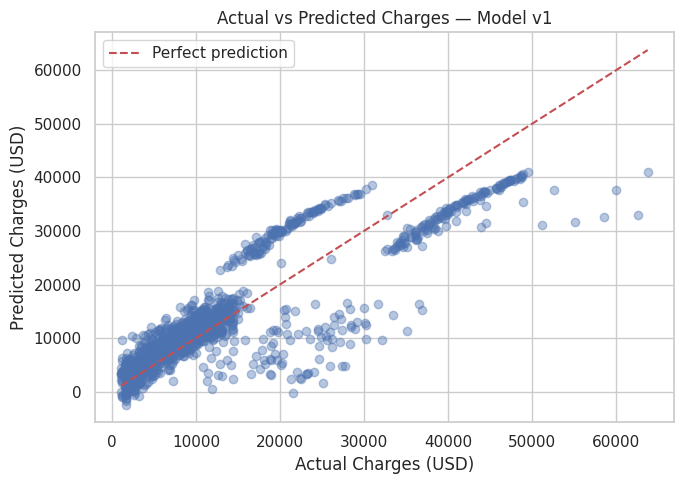

In [19]:
# Scatter plot: actual vs predicted charges
plt.figure(figsize=(7, 5))
plt.scatter(targets_v1, pred_v1, alpha=0.4)
plt.plot([targets_v1.min(), targets_v1.max()],
         [targets_v1.min(), targets_v1.max()],
         'r--', linewidth=1.5, label='Perfect prediction')
plt.title('Actual vs Predicted Charges — Model v1')
plt.xlabel('Actual Charges (USD)')
plt.ylabel('Predicted Charges (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Exploring Region — One-Hot Encoding

The `region` column has 4 unique values: northeast, northwest, southeast, southwest.  
Unlike `smoker` or `sex` (which are binary), region has no natural numeric ordering —  
assigning numbers 1–4 would imply a false hierarchy (e.g. northeast "greater than" northwest).

**One-hot encoding** is the correct approach here: it creates one binary column per category.  
A row is assigned `1` in its region's column and `0` in all others.

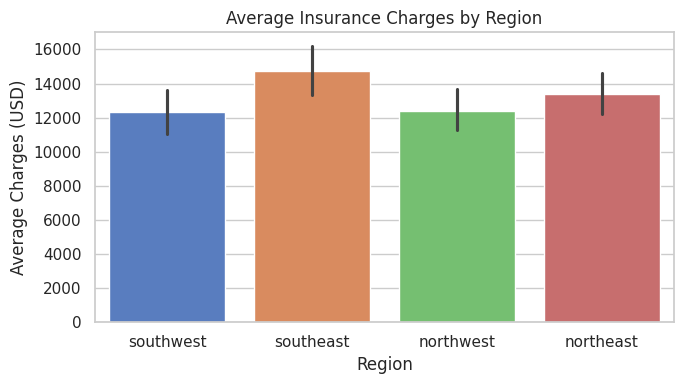

In [20]:
# Visualise average charges by region — are there meaningful regional differences?
plt.figure(figsize=(7, 4))
sns.barplot(data=medical_df, x='region', y='charges', palette='muted', hue='region', legend=False)
plt.title('Average Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges (USD)')
plt.tight_layout()
plt.show()

In [21]:
# Fit the encoder on the region column to learn its 4 unique categories
enc = preprocessing.OneHotEncoder(sparse_output=False)
enc.fit(medical_df[['region']])

print("Learned region categories:")
print(enc.categories_)

Learned region categories:
[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]


In [22]:
# Transform the region column into 4 binary columns
# Each row gets a 1 in its region's column and 0 in all others
onehot_array = enc.transform(medical_df[['region']])

# Convert to a named DataFrame for readability before joining
region_encoded_df = pd.DataFrame(
    onehot_array,
    columns=['northeast', 'northwest', 'southeast', 'southwest'],
    index=medical_df.index
)

# Join the encoded region columns to the main DataFrame using pd.concat —
# this avoids the pandas PerformanceWarning that occurs when inserting
# multiple columns into an existing DataFrame one at a time
medical_df = pd.concat([medical_df, region_encoded_df], axis=1)

print("Region columns added. Updated DataFrame shape:", medical_df.shape)
medical_df[['region', 'northeast', 'northwest', 'southeast', 'southwest']].head(8)

Region columns added. Updated DataFrame shape: (1338, 13)


,region,northeast,northwest,southeast,southwest
0,southwest,0.0,0.0,0.0,1.0
1,southeast,0.0,0.0,1.0,0.0
2,southeast,0.0,0.0,1.0,0.0
3,northwest,0.0,1.0,0.0,0.0
4,northwest,0.0,1.0,0.0,0.0
5,southeast,0.0,0.0,1.0,0.0
6,southeast,0.0,0.0,1.0,0.0
7,northwest,0.0,1.0,0.0,0.0


## 9. Final Model — All Features Including Region

We now include the one-hot encoded region columns alongside all other features.  
This is our most complete model — it uses every available predictor.

> **Note:** We drop one region column (`southwest`) to avoid **dummy variable trap** —  
> when all 4 region columns are included, any one of them is perfectly predictable  
> from the other three, which causes multicollinearity issues in linear regression.

In [23]:
# Final feature set — numeric, label-encoded, and one-hot encoded region
# We drop 'southwest' to avoid perfect multicollinearity (dummy variable trap)
inputs_v2  = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code',
                          'northeast', 'northwest', 'southeast']]
targets_v2 = medical_df['charges']

model_v2 = LinearRegression()
model_v2.fit(inputs_v2, targets_v2)
pred_v2 = model_v2.predict(inputs_v2)

# Final model performance metrics
rmse_v2 = root_mean_squared_error(targets_v2, pred_v2)
r2_v2   = r2_score(targets_v2, pred_v2)

print("Final Model — All Features (including region)")
print(f"  RMSE : ${rmse_v2:,.2f}")
print(f"  R²   : {r2_v2:.4f}  ({r2_v2*100:.1f}% of variance explained)")
print()
print("Feature coefficients:")
for feature, coef in zip(inputs_v2.columns, model_v2.coef_):
    print(f"  {feature:<15}: ${coef:.2f}")

Final Model — All Features (including region)
  RMSE : $6,041.68
  R²   : 0.7509  (75.1% of variance explained)

Feature coefficients:
  age            : $256.86
  bmi            : $339.19
  children       : $475.50
  smoker_code    : $23848.53
  sex_code       : $-131.31
  northeast      : $960.05
  northwest      : $607.09
  southeast      : $-74.97


In [24]:
# Compare model performance before and after adding region
print("Model Comparison")
print("-" * 45)
print(f"{'Model':<30} {'RMSE':>8}  {'R²':>6}")
print("-" * 45)
print(f"{'v1 (no region)':<30} ${rmse_v1:>7,.0f}  {r2_v1:.4f}")
print(f"{'v2 (with region)':<30} ${rmse_v2:>7,.0f}  {r2_v2:.4f}")

Model Comparison
---------------------------------------------
Model                              RMSE      R²
---------------------------------------------
v1 (no region)                 $  6,056  0.7497
v2 (with region)               $  6,042  0.7509


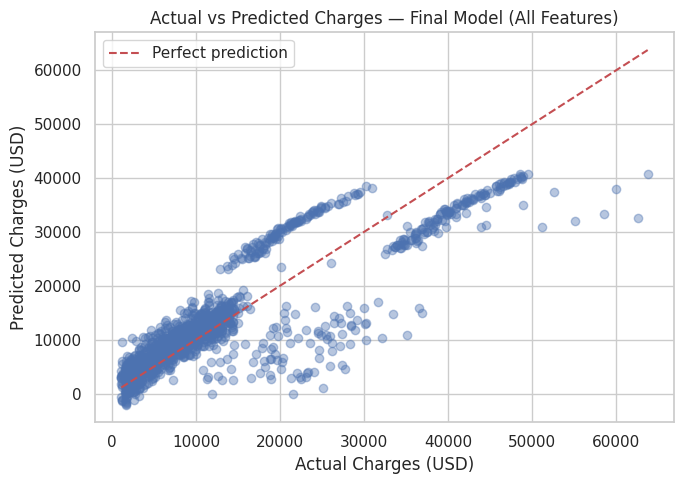

In [25]:
# Actual vs predicted — final model
plt.figure(figsize=(7, 5))
plt.scatter(targets_v2, pred_v2, alpha=0.4)
plt.plot([targets_v2.min(), targets_v2.max()],
         [targets_v2.min(), targets_v2.max()],
         'r--', linewidth=1.5, label='Perfect prediction')
plt.title('Actual vs Predicted Charges — Final Model (All Features)')
plt.xlabel('Actual Charges (USD)')
plt.ylabel('Predicted Charges (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Predict Charges for a New Individual

Here we demonstrate using the trained model on a single new data point —  
how this would work in a real insurance quoting application.

In [26]:
# Define a new individual's details
new_person = {
    'age': 35,
    'bmi': 27.5,
    'children': 2,
    'smoker': 'no',
    'sex': 'male',
    'region': 'northeast'
}

# Apply the same label encoding used during training
new_person['smoker_code'] = smoker_map[new_person['smoker']]
new_person['sex_code']    = sex_map[new_person['sex']]

# Apply one-hot encoding for region
region_input   = pd.DataFrame([[new_person['region']]], columns=['region'])
region_onehot  = enc.transform(region_input)
region_row     = dict(zip(['northeast', 'northwest', 'southeast', 'southwest'], region_onehot[0]))

# Build the final input row matching the exact column order the model was trained on
input_row = pd.DataFrame([{
    'age':        new_person['age'],
    'bmi':        new_person['bmi'],
    'children':   new_person['children'],
    'smoker_code': new_person['smoker_code'],
    'sex_code':   new_person['sex_code'],
    'northeast':  region_row['northeast'],
    'northwest':  region_row['northwest'],
    'southeast':  region_row['southeast']
    # southwest is intentionally excluded (dummy variable trap)
}])

predicted_charge = model_v2.predict(input_row)[0]
print(f"Predicted annual insurance charge: ${predicted_charge:,.2f}")

Predicted annual insurance charge: $7,198.94


---

## Summary

This notebook built a series of progressively more complete linear regression models  
to predict medical insurance charges from personal and demographic data.

### Model Progression

| Model | Features Used | R² Score |
|-------|--------------|----------|
| Simple (non-smokers) | age only | Low — age alone isn't enough |
| Multiple (non-smokers) | age + bmi | Better, but still limited |
| v1 (all data) | age, bmi, children, smoker, sex | Good — smoker is a strong signal |
| **v2 Final (all data)** | **all above + region** | **Best** |

### Key Takeaways

- **Smoking status is by far the strongest predictor** of insurance charges, with a correlation > 0.7
- **One feature is rarely enough** — multiple regression almost always outperforms simple regression
- **Label encoding works for binary categories** (yes/no, male/female) but not for multi-class categories with no natural order
- **One-hot encoding is correct for nominal categories** like region — it avoids implying a false numeric ranking
- **Avoid the dummy variable trap** —  drop one column when one-hot encoding to prevent perfect multicollinearity
- **RMSE and R² together** give a more complete picture of model quality than accuracy alone

